In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("Sample - Superstore.csv", encoding="latin1")

In [3]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [4]:
df.shape

(9994, 21)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [6]:
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [7]:
df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

In [10]:
df.drop("Row ID", axis = 1, inplace = True)

In [11]:
df.drop([
    'Order ID',
    'Customer ID',
    'Customer Name',
    'Product ID',
    'Product Name'
], axis = 1, inplace = True)

In [12]:
df.head(1)

,Order Date,Ship Date,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
0,11/8/2016,11/11/2016,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,261.96,2,0.0,41.9136


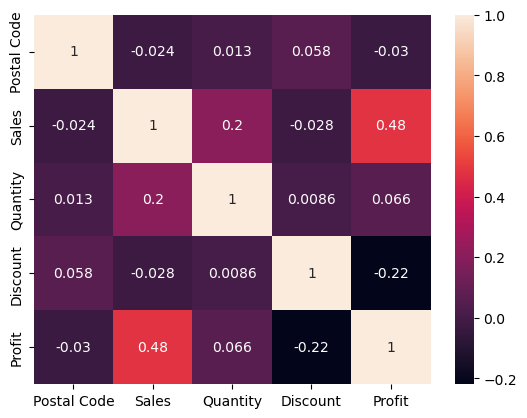

In [13]:
sns.heatmap(
    df.corr(numeric_only=True),
    annot = True
)
plt.show()

In [14]:
df.dtypes

Order Date       object
Ship Date        object
Ship Mode        object
Segment          object
Country          object
City             object
State            object
Postal Code       int64
Region           object
Category         object
Sub-Category     object
Sales           float64
Quantity          int64
Discount        float64
Profit          float64
dtype: object

In [15]:
df['Order Date'] = pd.to_datetime(df['Order Date'])

df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month
df['Quarter'] = df['Order Date'].dt.quarter
df['DayOfWeek'] = df['Order Date'].dt.dayofweek

In [16]:
df.head(1)

,Order Date,Ship Date,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit,Year,Month,Quarter,DayOfWeek
0,2016-11-08,11/11/2016,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,261.96,2,0.0,41.9136,2016,11,4,1


In [17]:
df.drop("Order Date", axis = 1, inplace = True)

In [18]:
df["Ship Mode"].value_counts()

Ship Mode
Standard Class    5968
Second Class      1945
First Class       1538
Same Day           543
Name: count, dtype: int64

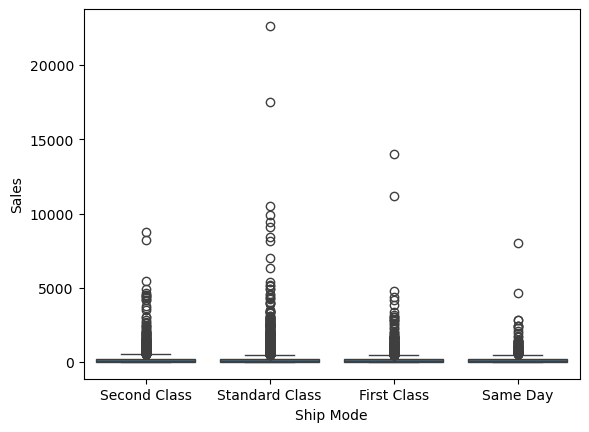

In [19]:
sns.boxplot(x="Ship Mode", y="Sales", data=df)
plt.show()

In [20]:
df = pd.get_dummies(df, columns=["Ship Mode"], drop_first=True)

In [21]:
df.head(1)

,Ship Date,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit,Year,Month,Quarter,DayOfWeek,Ship Mode_Same Day,Ship Mode_Second Class,Ship Mode_Standard Class
0,11/11/2016,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,261.96,2,0.0,41.9136,2016,11,4,1,False,True,False


In [22]:
df["Country"].value_counts()

Country
United States    9994
Name: count, dtype: int64

In [23]:
df.drop("Country", axis =1 , inplace = True)

In [24]:
df.dtypes

Ship Date                    object
Segment                      object
City                         object
State                        object
Postal Code                   int64
Region                       object
Category                     object
Sub-Category                 object
Sales                       float64
Quantity                      int64
Discount                    float64
Profit                      float64
Year                          int32
Month                         int32
Quarter                       int32
DayOfWeek                     int32
Ship Mode_Same Day             bool
Ship Mode_Second Class         bool
Ship Mode_Standard Class       bool
dtype: object

In [25]:
df.drop(["Ship Date", "Postal Code"], axis = 1, inplace = True)

In [26]:
df.dtypes

Segment                      object
City                         object
State                        object
Region                       object
Category                     object
Sub-Category                 object
Sales                       float64
Quantity                      int64
Discount                    float64
Profit                      float64
Year                          int32
Month                         int32
Quarter                       int32
DayOfWeek                     int32
Ship Mode_Same Day             bool
Ship Mode_Second Class         bool
Ship Mode_Standard Class       bool
dtype: object

In [27]:
df["Segment"].value_counts()

Segment
Consumer       5191
Corporate      3020
Home Office    1783
Name: count, dtype: int64

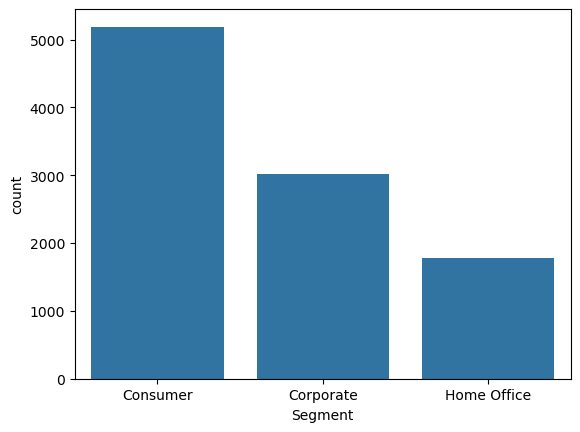

In [28]:
sns.countplot(data = df, x = "Segment")
plt.show()

In [29]:
df = pd.get_dummies(df, columns=["Segment"], drop_first=True)

In [30]:
df.head(1)

,City,State,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit,Year,Month,Quarter,DayOfWeek,Ship Mode_Same Day,Ship Mode_Second Class,Ship Mode_Standard Class,Segment_Corporate,Segment_Home Office
0,Henderson,Kentucky,South,Furniture,Bookcases,261.96,2,0.0,41.9136,2016,11,4,1,False,True,False,False,False


In [31]:
df.dtypes

City                         object
State                        object
Region                       object
Category                     object
Sub-Category                 object
Sales                       float64
Quantity                      int64
Discount                    float64
Profit                      float64
Year                          int32
Month                         int32
Quarter                       int32
DayOfWeek                     int32
Ship Mode_Same Day             bool
Ship Mode_Second Class         bool
Ship Mode_Standard Class       bool
Segment_Corporate              bool
Segment_Home Office            bool
dtype: object

In [32]:
df["City"].value_counts()

City
New York City      915
Los Angeles        747
Philadelphia       537
San Francisco      510
Seattle            428
                  ... 
Glenview             1
Missouri City        1
Rochester Hills      1
Palatine             1
Manhattan            1
Name: count, Length: 531, dtype: int64

In [33]:
df.drop("City", axis=1, inplace=True)

In [34]:
df["Region"].value_counts()

Region
West       3203
East       2848
Central    2323
South      1620
Name: count, dtype: int64

In [35]:
df = pd.get_dummies(df, columns=["Region"], drop_first=True)

In [36]:
df.head(1)

,State,Category,Sub-Category,Sales,Quantity,Discount,Profit,Year,Month,Quarter,DayOfWeek,Ship Mode_Same Day,Ship Mode_Second Class,Ship Mode_Standard Class,Segment_Corporate,Segment_Home Office,Region_East,Region_South,Region_West
0,Kentucky,Furniture,Bookcases,261.96,2,0.0,41.9136,2016,11,4,1,False,True,False,False,False,False,True,False


In [37]:
df["Category"].value_counts()

Category
Office Supplies    6026
Furniture          2121
Technology         1847
Name: count, dtype: int64

In [38]:
df["Sub-Category"].value_counts()

Sub-Category
Binders        1523
Paper          1370
Furnishings     957
Phones          889
Storage         846
Art             796
Accessories     775
Chairs          617
Appliances      466
Labels          364
Tables          319
Envelopes       254
Bookcases       228
Fasteners       217
Supplies        190
Machines        115
Copiers          68
Name: count, dtype: int64

In [39]:
df = pd.get_dummies(
    df,
    columns=["Category", "Sub-Category"],
    drop_first=True
)

In [40]:
df.head()

,State,Sales,Quantity,Discount,Profit,Year,Month,Quarter,DayOfWeek,Ship Mode_Same Day,...,Sub-Category_Envelopes,Sub-Category_Fasteners,Sub-Category_Furnishings,Sub-Category_Labels,Sub-Category_Machines,Sub-Category_Paper,Sub-Category_Phones,Sub-Category_Storage,Sub-Category_Supplies,Sub-Category_Tables
0,Kentucky,261.9600,2,0.00,41.9136,2016,11,4,1,False,...,False,False,False,False,False,False,False,False,False,False
1,Kentucky,731.9400,3,0.00,219.5820,2016,11,4,1,False,...,False,False,False,False,False,False,False,False,False,False
2,California,14.6200,2,0.00,6.8714,2016,6,2,6,False,...,False,False,False,True,False,False,False,False,False,False
3,Florida,957.5775,5,0.45,-383.0310,2015,10,4,6,False,...,False,False,False,False,False,False,False,False,False,True
4,Florida,22.3680,2,0.20,2.5164,2015,10,4,6,False,...,False,False,False,False,False,False,False,True,False,False


In [41]:
df.dtypes

State                        object
Sales                       float64
Quantity                      int64
Discount                    float64
Profit                      float64
Year                          int32
Month                         int32
Quarter                       int32
DayOfWeek                     int32
Ship Mode_Same Day             bool
Ship Mode_Second Class         bool
Ship Mode_Standard Class       bool
Segment_Corporate              bool
Segment_Home Office            bool
Region_East                    bool
Region_South                   bool
Region_West                    bool
Category_Office Supplies       bool
Category_Technology            bool
Sub-Category_Appliances        bool
Sub-Category_Art               bool
Sub-Category_Binders           bool
Sub-Category_Bookcases         bool
Sub-Category_Chairs            bool
Sub-Category_Copiers           bool
Sub-Category_Envelopes         bool
Sub-Category_Fasteners         bool
Sub-Category_Furnishings    

In [42]:
state_mean = df.groupby("State")["Sales"].mean()
df["State_encoded"] = df["State"].map(state_mean)
df = df.drop("State", axis=1)

In [43]:
df.head(1)

,Sales,Quantity,Discount,Profit,Year,Month,Quarter,DayOfWeek,Ship Mode_Same Day,Ship Mode_Second Class,...,Sub-Category_Fasteners,Sub-Category_Furnishings,Sub-Category_Labels,Sub-Category_Machines,Sub-Category_Paper,Sub-Category_Phones,Sub-Category_Storage,Sub-Category_Supplies,Sub-Category_Tables,State_encoded
0,261.96,2,0.0,41.9136,2016,11,4,1,False,True,...,False,False,False,False,False,False,False,False,False,263.25


In [44]:
df.dtypes

Sales                       float64
Quantity                      int64
Discount                    float64
Profit                      float64
Year                          int32
Month                         int32
Quarter                       int32
DayOfWeek                     int32
Ship Mode_Same Day             bool
Ship Mode_Second Class         bool
Ship Mode_Standard Class       bool
Segment_Corporate              bool
Segment_Home Office            bool
Region_East                    bool
Region_South                   bool
Region_West                    bool
Category_Office Supplies       bool
Category_Technology            bool
Sub-Category_Appliances        bool
Sub-Category_Art               bool
Sub-Category_Binders           bool
Sub-Category_Bookcases         bool
Sub-Category_Chairs            bool
Sub-Category_Copiers           bool
Sub-Category_Envelopes         bool
Sub-Category_Fasteners         bool
Sub-Category_Furnishings       bool
Sub-Category_Labels         

In [45]:
X = df.drop("Sales", axis = 1)

In [46]:
y = df["Sales"]

In [47]:
from sklearn.preprocessing import StandardScaler

In [48]:
from sklearn.model_selection import train_test_split

In [49]:
scaler = StandardScaler()

In [50]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.20, random_state=42) 

In [51]:
X_train.shape

(7995, 34)

In [52]:
y_train.shape

(7995,)

In [53]:
X_train_scaled = scaler.fit_transform(X_train)

In [54]:
X_test_scaled = scaler.transform(X_test)

In [55]:
from sklearn.linear_model import LinearRegression

In [56]:
model = LinearRegression()

In [57]:
model.fit(X_train_scaled, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [58]:
y_pred = model.predict(X_test_scaled)

In [59]:
comparison = pd.DataFrame({
    "Actual" : y_test,
    "Predicted" : y_pred
})

In [60]:
from sklearn.metrics import mean_squared_error, r2_score

In [61]:
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse}")
print(f"R2 Score (Variance Explained): {r2}")

Mean Squared Error: 567194.2151677613
R2 Score (Variance Explained): 0.03979174022609233


In [62]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

In [63]:
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

In [64]:
rf_model.fit(X_train_scaled, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [65]:
y_pred_rf = rf_model.predict(X_test_scaled)
print("Random Forest R2 Score:", r2_score(y_test, y_pred_rf))

Random Forest R2 Score: 0.5980549494844638
